In [ ]:
import numpy as np
import pandas as pd
from geopy.distance import great_circle
import matplotlib.pyplot as plt
import pyproj
import seaborn as sns
import statistics
from scipy.stats import ttest_ind

In [ ]:
#The following code was exectuded outside google colab using Spyder IDE for Python.
#This code created the ECA coordinate datasets and was saved in google drive.

#import pandas as pd

#ECA_NA_P = pd.read_excel("ECA North America Pacific.xlsx")
#ECA_NA_A = pd.read_excel("ECA North America Atlantic.xlsx")
#ECA_NA_H = pd.read_excel("ECA North America Hawaii.xlsx")
#ECA_USC = pd.read_excel("ECA US Caribbean.xlsx")

#ECA_NA_P = ECA_NA_P.drop(columns=['LAT D','LAT M','LAT S','LON D','LON M','LON S'])
#ECA_NA_A = ECA_NA_A.drop(columns=['LAT D','LAT M','LAT S','LON D','LON M','LON S'])
#ECA_NA_H = ECA_NA_H.drop(columns=['LAT D','LAT M','LAT S','LON D','LON M','LON S'])
#ECA_USC = ECA_USC.drop(columns=['LAT D','LAT M','LAT S','LON D','LON M','LON S'])

#print(ECA_NA_H.head())
#print(ECA_USC.head())

#ECA_NA_P = ECA_NA_P.to_csv('ECA_North_America_Pacific.csv', index=False)
#ECA_NA_A = ECA_NA_A.to_csv('ECA_North_America_Atlantic.csv', index=False)
#ECA_NA_H = ECA_NA_H.to_csv('ECA_North_America_Hawaii.csv', index=False)
#ECA_USC = ECA_USC.to_csv('ECA_US_Caribbean.csv', index=False)

#print("Complete")

In [ ]:
ECA_NA_P_ID = '16OhWISA3xqqmmcsq18q6FmzRkbb9MjWS'
#https://drive.google.com/file/d/16OhWISA3xqqmmcsq18q6FmzRkbb9MjWS/view?usp=sharing
ECA_US_C_ID = '179DFUFo4lkDifI-nXgoO1D-r18MZ1jrS'
#https://drive.google.com/file/d/179DFUFo4lkDifI-nXgoO1D-r18MZ1jrS/view?usp=sharing
ECA_NA_A_ID = '1uzhGoQ6GTg2MCKGWcov8kaeVsHrlQva7'
#https://drive.google.com/file/d/1uzhGoQ6GTg2MCKGWcov8kaeVsHrlQva7/view?usp=sharing
ECA_NA_H_ID = '1ALj6xLqz2XN7sx38AqktoB00ZRah1RCc'
#https://drive.google.com/file/d/1ALj6xLqz2XN7sx38AqktoB00ZRah1RCc/view?usp=sharing

ECA_NA_P = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ECA_NA_P_ID}')
ECA_NA_P = ECA_NA_P.reset_index()
ECA_NA_A = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ECA_NA_A_ID}')
ECA_NA_A = ECA_NA_A.reset_index()
ECA_NA_H = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ECA_NA_H_ID}')
ECA_NA_H = ECA_NA_H.reset_index()
ECA_US_C = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ECA_US_C_ID}')
ECA_US_C = ECA_US_C.reset_index()

ship_performance_ID = '1z7pU_aaZG6vMNcJ40GDNhWO0p1fDW22Z'
#https://drive.google.com/file/d/1z7pU_aaZG6vMNcJ40GDNhWO0p1fDW22Z/view?usp=sharing
ship_fuel_consumption_ID = '1XuiWqo2_wKSuPscY1lmPglRQPsY9i4H8'
#https://drive.google.com/file/d/1XuiWqo2_wKSuPscY1lmPglRQPsY9i4H8/view?usp=sharing
ship_reporting_ID = '1cobAG3WNlp2hlCZDI1BYA1LIQDrl0RLL'
#https://drive.google.com/file/d/1cobAG3WNlp2hlCZDI1BYA1LIQDrl0RLL/view?usp=sharing

ship_performance = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ship_performance_ID}')
ship_fuel_consumption = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ship_fuel_consumption_ID}')
ship_reporting = pd.read_csv(f'https://drive.google.com/uc?export=download&id={ship_reporting_ID}')

bunker_fuel_prices_ID = '1b1Ps2TIfPKFsUy9gABtewRGeqXSVWowU'
#https://drive.google.com/file/d/1b1Ps2TIfPKFsUy9gABtewRGeqXSVWowU/view?usp=sharing

bunker_fuel_prices = pd.read_csv(f'https://drive.google.com/uc?export=download&id={bunker_fuel_prices_ID}')


In [ ]:
ship_fuel_consumption.head(7)

,Column1,Diesel /\nGas Oil\n(MDO /\nMGO),Heavy Fuel\nOil (HFO),Light Fuel\nOil (LFO),Ethane,Ethanol,Liquefied\nNatural\nGas (LNG),Liquefied\nPetroleum\nGas (LPG)\n- Butane,Liquefied\nPetroleum\nGas (LPG)\n- Propane,Methanol,Other
0,Containership,4858186.0,43113643.0,10182858.0,0.0,0.0,468540.0,20064.0,3990.0,0.0,310050.0
1,"Less than 10,000 DWT",179784.0,465430.0,159148.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0
2,"10,000 ? DWT < 15,000",387670.0,1668478.0,573355.0,0.0,0.0,3467.0,0.0,0.0,0.0,1417.0
3,"15,000 ? DWT < 40,000",848742.0,7948001.0,2347012.0,0.0,0.0,24400.0,0.0,3990.0,0.0,6940.0
4,"40,000 ? DWT < 80,000",1288696.0,10344054.0,3161549.0,0.0,0.0,13898.0,0.0,0.0,0.0,73723.0
5,"80,000 ? DWT < 120,000",1041756.0,9777012.0,1855205.0,0.0,0.0,5326.0,0.0,0.0,0.0,87810.0
6,"120,000 ? DWT <\n200,000",978610.0,10415009.0,1832604.0,0.0,0.0,271426.0,0.0,0.0,0.0,137286.0


In [ ]:
ship_reporting.head(7)

,Column1,Number\nof ships,Gross tonnage,Deadweight\ntonnage,Distance travelled,Hours under\nway,CO_{2}\nemissions,AER for\neach\nEEDI\nship Size,cgDIST\nfor each\nEEDI\nship Size
0,Containership,5076.0,279735936.0,317809559.0,371674845.0,28556513.0,183739286.0,7.31,-
1,"Less than 10,000 DWT",242.0,1675570.0,2043832.0,12773831.0,1154197.0,2527550.0,23.31,-
2,"10,000 ? DWT < 15,000",616.0,6169096.0,7763370.0,36815156.0,3104221.0,8258176.0,17.82,-
3,"15,000 ? DWT < 40,000",1634.0,36141260.0,45221966.0,110166487.0,8731001.0,34956815.0,11.34,-
4,"40,000 ? DWT < 80,000",1122.0,54350135.0,64631189.0,90747365.0,6829180.0,46393513.0,8.81,-
5,"80,000 ? DWT < 120,000",668.0,59680995.0,67352581.0,56778551.0,4082967.0,39764038.0,6.90,-
6,"120,000 ? DWT < 200,000",654.0,92250986.0,98751618.0,54580390.0,3945974.0,42365386.0,5.15,-


In [ ]:
ship_fuel_consumption_reporting = pd.merge(ship_fuel_consumption, ship_reporting, on='Column1', how='inner')
ship_fuel_consumption_reporting = ship_fuel_consumption_reporting.drop(columns=['Heavy Fuel\nOil (HFO)','Ethane','Ethanol','Liquefied\nNatural\nGas (LNG)','Liquefied\nPetroleum\nGas (LPG)\n- Butane',
                                                                                'Liquefied\nPetroleum\nGas (LPG)\n- Propane','Methanol','Other','Distance travelled','Hours under\nway','CO_{2}\nemissions',
                                                                                'AER for\neach\nEEDI\nship Size','cgDIST\nfor each\nEEDI\nship Size','Gross tonnage','Deadweight\ntonnage'])

ship_fuel_consumption_reporting['MGO_Consumption_per_Ship(liter/hour)'] = (((ship_fuel_consumption_reporting['Diesel /\nGas Oil\n(MDO /\nMGO)'] /
                                                                        ship_fuel_consumption_reporting['Number\nof ships']) / 365) / 24) * 2831.6846592
ship_fuel_consumption_reporting['LFO_Consumption_per_Ship(liter/hour)'] = (((ship_fuel_consumption_reporting['Light Fuel\nOil (LFO)'] /
                                                                        ship_fuel_consumption_reporting['Number\nof ships']) / 365) / 24) * 2831.6846592

ship_fuel_consumption_reporting.head(7)

,Column1,Diesel /\nGas Oil\n(MDO /\nMGO),Light Fuel\nOil (LFO),Number\nof ships,MGO_Consumption_per_Ship(liter/hour),LFO_Consumption_per_Ship(liter/hour)
0,Containership,4858186.0,10182858.0,5076.0,309.380763,648.468457
1,"Less than 10,000 DWT",179784.0,159148.0,242.0,240.146607,212.582055
2,"10,000 ? DWT < 15,000",387670.0,573355.0,616.0,203.433403,300.873317
3,"15,000 ? DWT < 40,000",848742.0,2347012.0,1634.0,167.905307,464.305726
4,"40,000 ? DWT < 80,000",1288696.0,3161549.0,1122.0,371.277307,910.852054
5,"80,000 ? DWT < 120,000",1041756.0,1855205.0,668.0,504.115824,897.751678
6,"200,000 DWT and above",132894.0,253985.0,139.0,309.051855,590.655225


In [ ]:
ship_performance.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [ ]:
container_performance = ship_performance[ship_performance['Ship_Type'] == 'Container Ship']
container_performance = container_performance[container_performance['Route_Type'] == 'Long-haul']
container_performance = container_performance.drop(columns=['Engine_Type', 'Maintenance_Status', 'Draft_meters','Weather_Condition','Revenue_per_Voyage_USD','Efficiency_nm_per_kWh','Seasonal_Impact_Score','Weekly_Voyage_Count'])
container_performance.head()

,Date,Ship_Type,Route_Type,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Cargo_Weight_tons,Operational_Cost_USD,Turnaround_Time_hours,Average_Load_Percentage
2,2023-06-18,Container Ship,Long-haul,20.749747,1648.556685,658.874144,178.040917,448543.404044,49.418150,96.218244
9,2023-08-06,Container Ship,Long-haul,23.227101,2685.401654,1588.792282,1843.438252,149790.209291,63.742761,79.451330
25,2023-11-26,Container Ship,Long-haul,17.671558,1845.764699,1708.795355,1883.332572,275322.820473,22.346127,57.937525
71,2023-09-10,Container Ship,Long-haul,15.378922,1144.165975,1648.530646,642.686238,361888.992501,47.856124,73.004925
75,2023-10-08,Container Ship,Long-haul,24.074836,2397.891603,941.271948,1072.653418,173623.449374,50.161965,71.716908


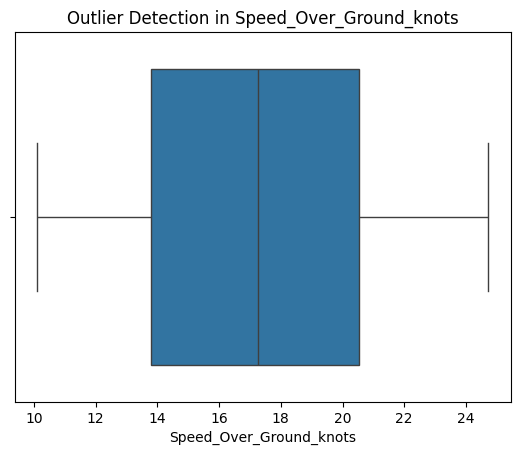

In [ ]:
sns.boxplot(x=container_performance['Speed_Over_Ground_knots'])
plt.title("Outlier Detection in Speed_Over_Ground_knots")
plt.show()

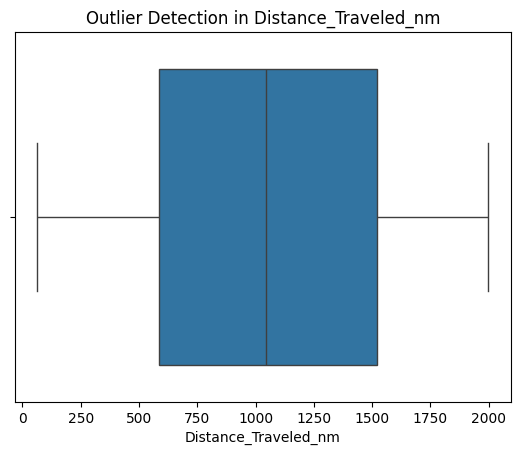

In [ ]:
sns.boxplot(x=container_performance['Distance_Traveled_nm'])
plt.title("Outlier Detection in Distance_Traveled_nm")
plt.show()

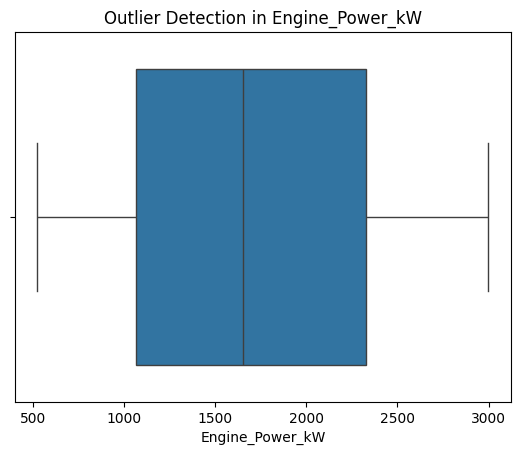

In [ ]:
sns.boxplot(x=container_performance['Engine_Power_kW'])
plt.title("Outlier Detection in Engine_Power_kW")
plt.show()

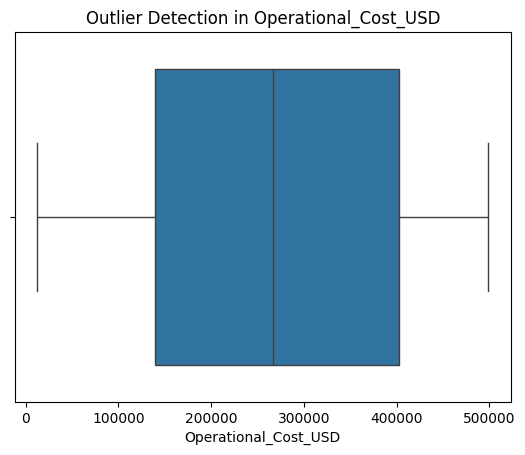

In [ ]:
sns.boxplot(x=container_performance['Operational_Cost_USD'])
plt.title("Outlier Detection in Operational_Cost_USD")
plt.show()

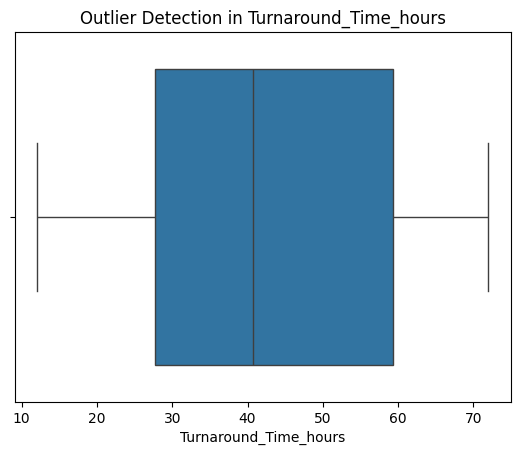

In [ ]:
sns.boxplot(x=container_performance['Turnaround_Time_hours'])
plt.title("Outlier Detection in Turnaround_Time_hours")
plt.show()

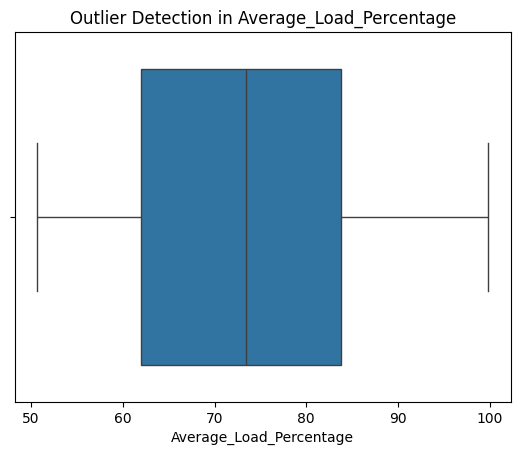

In [ ]:
sns.boxplot(x=container_performance['Average_Load_Percentage'])
plt.title("Outlier Detection in Average_Load_Percentage")
plt.show()

In [ ]:
container_performance['Time_of_journey(hrs)'] = container_performance['Distance_Traveled_nm'] / container_performance['Speed_Over_Ground_knots']
container_performance['Power_Consumption_to_Time(MJ)'] = container_performance['Engine_Power_kW'] * container_performance['Time_of_journey(hrs)'] * 3.6 #conversion from kWh to MJ
container_performance['Unit_Operations_Cost(USD)'] = container_performance['Operational_Cost_USD'] / container_performance['Cargo_Weight_tons']
container_performance.head()

,Date,Ship_Type,Route_Type,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Cargo_Weight_tons,Operational_Cost_USD,Turnaround_Time_hours,Average_Load_Percentage,Time_of_journey(hrs),Power_Consumption_to_Time(MJ),Unit_Operations_Cost(USD)
2,2023-06-18,Container Ship,Long-haul,20.749747,1648.556685,658.874144,178.040917,448543.404044,49.418150,96.218244,31.753359,188449.961128,2519.327650
9,2023-08-06,Container Ship,Long-haul,23.227101,2685.401654,1588.792282,1843.438252,149790.209291,63.742761,79.451330,68.402523,661277.696319,81.255886
25,2023-11-26,Container Ship,Long-haul,17.671558,1845.764699,1708.795355,1883.332572,275322.820473,22.346127,57.937525,96.697491,642530.935735,146.189167
71,2023-09-10,Container Ship,Long-haul,15.378922,1144.165975,1648.530646,642.686238,361888.992501,47.856124,73.004925,107.194159,441532.472785,563.088131
75,2023-10-08,Container Ship,Long-haul,24.074836,2397.891603,941.271948,1072.653418,173623.449374,50.161965,71.716908,39.097752,337507.814355,161.863512


In [ ]:
print("NAN values in the Container Performance dataframe:\n", container_performance.isna().sum())
print()
print("Number of Duplicates in the Container Performance dataframe: ", container_performance.duplicated().sum())

NAN values in the Container Performance dataframe:
 Date                             0
Ship_Type                        0
Route_Type                       0
Speed_Over_Ground_knots          0
Engine_Power_kW                  0
Distance_Traveled_nm             0
Cargo_Weight_tons                0
Operational_Cost_USD             0
Turnaround_Time_hours            0
Average_Load_Percentage          0
Time_of_journey(hrs)             0
Power_Consumption_to_Time(MJ)    0
Unit_Operations_Cost(USD)        0
dtype: int64

Number of Duplicates in the Container Performance dataframe:  0


In [ ]:
container_performance.describe()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Cargo_Weight_tons,Operational_Cost_USD,Turnaround_Time_hours,Average_Load_Percentage,Time_of_journey(hrs),Power_Consumption_to_Time(MJ),Unit_Operations_Cost(USD)
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,1.730000e+02,173.000000
mean,17.145204,1682.865527,1052.925784,929.369172,268433.771484,42.910501,74.182021,65.871983,3.958786e+05,614.299266
std,4.103765,708.523129,573.390020,558.565978,143364.049615,17.834693,14.145498,41.628490,3.153864e+05,1018.668225
min,10.112513,524.842506,64.098192,69.876267,12619.210268,12.091002,50.678731,3.519926,9.408491e+03,9.757923
25%,13.783020,1065.839785,586.651322,465.397753,139043.919175,27.652926,61.985358,31.283042,1.730705e+05,145.892836
50%,17.264770,1650.893562,1043.299860,847.418070,266359.224719,40.710159,73.387491,59.555119,2.847252e+05,280.194854
75%,20.534542,2325.631313,1519.373284,1384.745236,403069.404640,59.367844,83.846318,96.510639,5.449617e+05,632.145856
max,24.725075,2998.685375,1998.035422,1981.187359,498989.085044,71.972415,99.864101,181.908812,1.326831e+06,6486.298887


In [ ]:
bunker_fuel_prices.head()

,Day,Month,Year,"VLSFO Fuel Oil, IMO 2020 Grade, 0.5%",Marine Gas Oil,"Intermdiate Fuel Oil, 180cSt","Intermdiate Fuel Oil, 380cSt"
0,01/29/2019,January,2019,NaN,$636.5,$429,$400.5
1,01/30/2019,January,2019,NaN,$640.5,$436,$407.5
2,01/31/2019,January,2019,NaN,$642.5,$439,$410
3,02/01/2019,February,2019,NaN,$643.5,$440,$410
4,02/04/2019,February,2019,NaN,$648.5,$438.5,$414.5


In [ ]:
bunker_fuel_prices['Marine Gas Oil'] = bunker_fuel_prices['Marine Gas Oil'].str.replace('$','')
bunker_fuel_prices['Marine Gas Oil'] = bunker_fuel_prices['Marine Gas Oil'].str.replace(',','')
bunker_fuel_prices['Marine Gas Oil'] = bunker_fuel_prices['Marine Gas Oil'].astype(float)
bunker_fuel_prices['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'] = bunker_fuel_prices['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'].str.replace('$','')
bunker_fuel_prices['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'] = bunker_fuel_prices['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'].str.replace(',','')
bunker_fuel_prices['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'] = bunker_fuel_prices['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'].astype(float)

In [ ]:
bunker_fuel_prices['Day'] = pd.to_datetime(bunker_fuel_prices['Day'])
bunker_fuel_prices = bunker_fuel_prices[bunker_fuel_prices['Day'] >= '2024-01-01']
bunker_fuel_prices = bunker_fuel_prices[bunker_fuel_prices['Day'] <= '2025-01-01']
bunker_fuel_prices = bunker_fuel_prices.rename(columns={'Day': 'Date'})
bunker_fuel_prices = bunker_fuel_prices.drop(columns=['Intermdiate Fuel Oil, 180cSt','Intermdiate Fuel Oil, 380cSt'])
bunker_fuel_prices.head()

,Date,Month,Year,"VLSFO Fuel Oil, IMO 2020 Grade, 0.5%",Marine Gas Oil
1283,2024-01-01,January,2024,637.0,854.0
1284,2024-01-02,January,2024,636.0,852.0
1285,2024-01-03,January,2024,633.5,840.0
1286,2024-01-04,January,2024,633.5,841.5
1287,2024-01-05,January,2024,635.0,841.0


In [ ]:
print("NAN values in the Bunker Fuel dataframe:\n", bunker_fuel_prices.isna().sum())
print()
print("Number of Duplicates in the Bunker fuel dataframe: ", bunker_fuel_prices.duplicated().sum())

NAN values in the Bunker Fuel dataframe:
 Date                                    0
Month                                   0
Year                                    0
VLSFO Fuel Oil, IMO 2020 Grade, 0.5%    0
Marine Gas Oil                          0
dtype: int64

Number of Duplicates in the Bunker fuel dataframe:  0


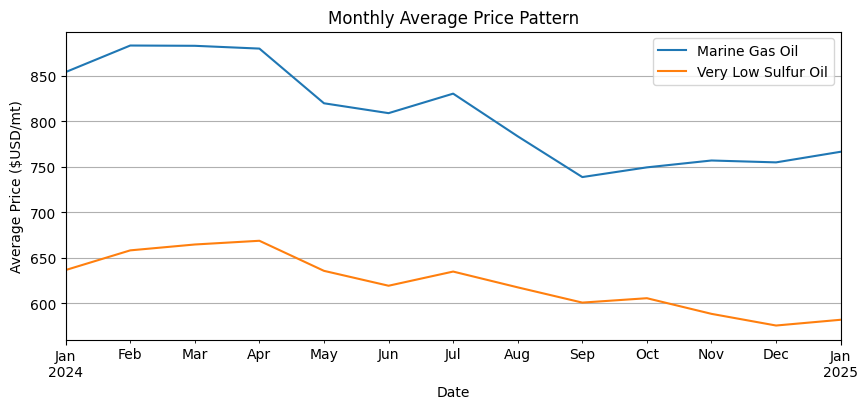

In [ ]:
price = bunker_fuel_prices
price = price.set_index('Date')

monthly_df = price['Marine Gas Oil'].resample('ME').mean().to_frame(name='Marine Gas Oil')
monthly_df_2 = price['VLSFO Fuel Oil, IMO 2020 Grade, 0.5%'].resample('ME').mean().to_frame(name='Very Low Sulfur Oil')
monthly_df['Month_Name'] = monthly_df.index.strftime('%B')
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month_Num'] = monthly_df.index.month

monthly_df['Marine Gas Oil'].plot(figsize=(10, 4), title="Monthly Average Price Pattern")
monthly_df_2['Very Low Sulfur Oil'].plot(figsize=(10, 4), title="Monthly Average Price Pattern")
plt.ylabel("Average Price ($USD/mt)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
fuels = pd.DataFrame.join(monthly_df,monthly_df_2)
fuels['Ratio_of_MGO_to_VLSFO'] = fuels['Marine Gas Oil']/fuels['Very Low Sulfur Oil']

fuels.head(12)

,Marine Gas Oil,Month_Name,Year,Month_Num,Very Low Sulfur Oil,Ratio_of_MGO_to_VLSFO
Date,,,,,,
2024-01-31,854.021739,January,2024,1,636.608696,1.341518
2024-02-29,883.166667,February,2024,2,658.214286,1.341762
2024-03-31,882.857143,March,2024,3,664.666667,1.328271
2024-04-30,879.795455,April,2024,4,668.750000,1.315582
2024-05-31,819.739130,May,2024,5,635.717391,1.289471
2024-06-30,808.900000,June,2024,6,619.375000,1.305994
2024-07-31,830.326087,July,2024,7,634.934783,1.307734
2024-08-31,783.454545,August,2024,8,617.590909,1.268566
2024-09-30,738.714286,September,2024,9,600.857143,1.229434


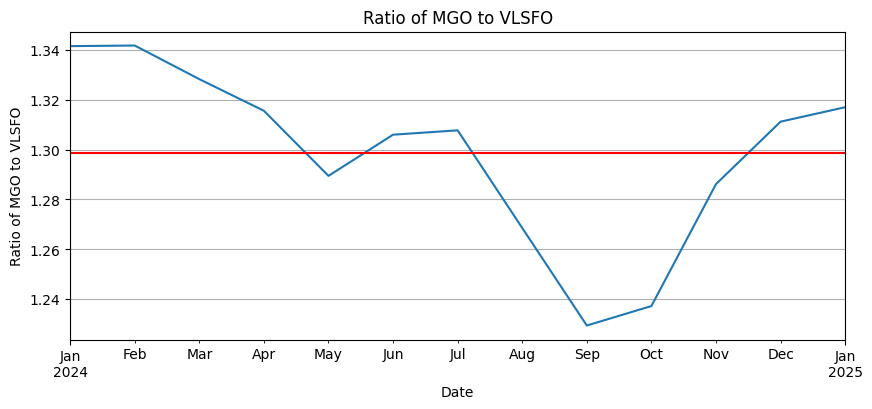

The average ratio of MGO to VLSFO is 1.298
The median ratio of MGO to VLSFO is 1.308
The maximum ratio of MGO to VLSFO is 1.342
The minimum ratio of MGO to VLSFO is 1.229


In [ ]:
monthly_df = fuels['Ratio_of_MGO_to_VLSFO'].resample('ME').mean().to_frame(name='Ratio of MGO to VLSFO')
monthly_df['Month_Name'] = monthly_df.index.strftime('%B')
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month_Num'] = monthly_df.index.month

monthly_df['Ratio of MGO to VLSFO'].plot(figsize=(10, 4), title="Ratio of MGO to VLSFO")
plt.axhline(monthly_df['Ratio of MGO to VLSFO'].mean(), color='r')
plt.ylabel("Ratio of MGO to VLSFO")
plt.grid(True)
plt.show()
print(f'The average ratio of MGO to VLSFO is {monthly_df['Ratio of MGO to VLSFO'].mean():.3f}')
print(f'The median ratio of MGO to VLSFO is {statistics.median(monthly_df['Ratio of MGO to VLSFO']):.3f}')
print(f'The maximum ratio of MGO to VLSFO is {monthly_df['Ratio of MGO to VLSFO'].max():.3f}')
print(f'The minimum ratio of MGO to VLSFO is {monthly_df['Ratio of MGO to VLSFO'].min():.3f}')

fuels.reset_index(inplace=True)

In [ ]:
#Given ECA_NA_A ports are all northwest of San Juan and there are only two coordinates to classify
#the northern barrier of ECA_US_C, there needs to be an extra coordinate to classify the shortest distance

Ax = 18.473212
Ay = -66.129759
Bx = 19.50777778
By = -65.28

mid_point = (((Ax+Bx)/2), ((Ay+By)/2))
inverse_rec = (-(By-Ay)/2, (Bx-Ax)/2)
shortest_dist_ECA_coord_PR = ((((Ax+Bx)/2))-(-(By-Ay)/2),(((Ay+By)/2))-((Bx-Ax)/2))

print(shortest_dist_ECA_coord_PR)
#Add shortest_dist_ECA_coord_PR to ECA_US_C Dataset to let Distance Code find this coordinate

(19.415374390000004, -66.22216239000001)


In [ ]:
min_speed = container_performance['Speed_Over_Ground_knots'].min()
max_speed = container_performance['Speed_Over_Ground_knots'].max()
avg_turnaround = container_performance['Turnaround_Time_hours'].mean()
avg_op_cost = container_performance['Operational_Cost_USD'].mean() * 0.7
power_consumption_to_time = container_performance['Power_Consumption_to_Time(MJ)'].mean()
mgo_con = ship_fuel_consumption_reporting.loc[1,'MGO_Consumption_per_Ship(liter/hour)']
lfo_con = ship_fuel_consumption_reporting.loc[1,'LFO_Consumption_per_Ship(liter/hour)']
load = container_performance['Average_Load_Percentage'].mean()

print(f'The minimum speed a container ship sails is {min_speed:.2f} knots and the maximum speed a container ship sails is {max_speed:.2f} knots')
print(f'The average turnaround time for a container ship is {avg_turnaround:.2f} hours')
print(f'The average operation cost, without considering fuel, for a container ship is ${avg_op_cost:.2f}')
print(f'The average power consumption to time for a container ship is {power_consumption_to_time:.2f} MJ')
print(f'The MGO consumption per container ship is {mgo_con:.2f} liter/hour')
print(f'The LFO consumption per container ship is {lfo_con:.2f} liter/hour')
print(f'The average load percentage for a container ship is {load:.2f}%')

The minimum speed a container ship sails is 10.11 knots and the maximum speed a container ship sails is 24.73 knots
The average turnaround time for a container ship is 42.91 hours
The average operation cost, without considering fuel, for a container ship is $187903.64
The average power consumption to time for a container ship is 395878.63 MJ
The MGO consumption per container ship is 240.15 liter/hour
The LFO consumption per container ship is 212.58 liter/hour
The average load percentage for a container ship is 74.18%


In [ ]:
#Choice between emission control areas based on where the user is embarking
print("List of Emission Control Areas:")
print("1. North American Pacific (ECA_NA_P)")
print("2. North America Hawaii (ECA_NA_H)")
print("3. North American Atlantic (ECA_NA_A)")
print("4. United States Caribbean (ECA_US_C)")
ECA_POL_finder = int(input("\nPlease select the number correlated with the ECA your Port of Loading (POL) is Located: "))

#if user chooses North American ECA (Pacific) then only choice for disembark is Hawaii ECA
if ECA_POL_finder == 1:
  print("\nList of Emission Control Areas:")
  print("2. North America Hawaii (ECA_NA_H)")
  ECA_POD_finder = int(input("\nPlease select the number correlated with the ECA your Port of Destination (POD) is Located: "))

  #list of container ship ports for the journey to commence given ECA_NA_P was chosen for POL
  print("\nContainer Ship ports of the US Pacific Seaboard")
  print("1. Port of Seattle")
  print("2. Port of Los Angeles")
  print("3. Port of Oakland")
  POL_finder = int(input("\nPlease select the number correlated with the POL: "))

  #list of container ship ports for the journey to conclude given ECA_NA_H was chosen for POD
  if POL_finder == 1:
    print("\nContainer Ship ports of Hawaii")
    print("1. Port of Honolulu")
    print("2. Port of Hilo")
    print("3. Port of Kahului")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 2:
    print("\nContainer Ship ports of Hawaii")
    print("1. Port of Honolulu")
    print("2. Port of Hilo")
    print("3. Port of Kahului")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 3:
    print("\nContainer Ship ports of the Hawaii")
    print("1. Port of Honolulu")
    print("2. Port of Hilo")
    print("3. Port of Kahului")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

#if user chooses Hawaii ECA then only choice for disembark is North American ECA (Pacific)
if ECA_POL_finder == 2:
  print("\nList of Emission Control Areas:")
  print("1. North American Pacific (ECA_NA_P)")
  ECA_POD_finder = int(input("\nPlease select the number correlated with the ECA your Port of Destination (POD) is Located: "))

  #list of container ship ports for the journey to commence given ECA_NA_P was chosen for POL
  print("\nContainer Ship ports of Hawaii")
  print("1. Port of Honolulu")
  print("2. Port of Hilo")
  print("3. Port of Kahului")
  POL_finder = int(input("\nPlease select the number correlated with the POL: "))

  #list of container ship ports for the journey to conclude given ECA_NA_H was chosen for POD
  if POL_finder == 1:
    print("\nContainer Ship ports of the US Pacific Seaboard")
    print("1. Port of Seattle")
    print("2. Port of Los Angeles")
    print("3. Port of Oakland")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 2:
    print("\nContainer Ship ports of the US Pacific Seaboard")
    print("1. Port of Seattle")
    print("2. Port of Los Angeles")
    print("3. Port of Oakland")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 3:
    print("\nContainer Ship ports of the US Pacific Seaboard")
    print("1. Port of Seattle")
    print("2. Port of Los Angeles")
    print("3. Port of Oakland")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

#if user chooses North American ECA (Atlantic) then only choice for disembark is Caribbean ECA
if ECA_POL_finder == 3:
  print("\nList of Emission Control Areas:")
  print("4. United States Caribbean (ECA_US_C)")
  ECA_POD_finder = int(input("\nPlease select the number correlated with the ECA your Port of Destination (POD) is Located: "))

  #list of container ship ports for the journey to commence given ECA_NA_A was chosen for POL
  print("\nContainer Ship ports of the US Atlantic Seaboard")
  print("1. Port of New York and New Jersey")
  print("2. Port of Virginia")
  print("3. Port of Charleston")
  print("4. Port of Savannah")
  POL_finder = int(input("\nPlease select the number correlated with the POL: "))

  #list of container ship ports for the journey to conclude given ECA_US_C was chosen for POD
  if POL_finder == 1:
    print("\nContainer Ship ports of the United States Caribbean")
    print("1. Port of San Juan, PR")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 2:
    print("\nContainer Ship ports of the United States Caribbean")
    print("1. Port of San Juan, PR")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 3:
    print("\nContainer Ship ports of the United States Caribbean")
    print("1. Port of San Juan, PR")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

  if POL_finder == 4:
    print("\nContainer Ship ports of the United States Caribbean")
    print("1. Port of San Juan, PR")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))

#if user chooses Caribbean ECA then only choice for disembark is North American ECA (Atlantic)
if ECA_POL_finder == 4:
  print("\nList of Emission Control Areas:")
  print("3. North American Atlantic (ECA_NA_A)")
  ECA_POD_finder = int(input("\nPlease select the number correlated with the ECA your Port of Destination (POD) is Located: "))

  #list of container ship ports for the journey to commence given ECA_NA_A was chosen for POL
  print("\nContainer Ship ports of the United States Caribbean")
  print("1. Port of San Juan, PR")

  POL_finder = int(input("\nPlease select the number correlated with the POL: "))

  #list of container ship ports for the journey to conclude given ECA_NA_H was chosen for POD
  if POL_finder == 1:
    print("\nContainer Ship ports of the US Atlantic Seaboard")
    print("1. Port of New York and New Jersey")
    print("2. Port of Virginia")
    print("3. Port of Charleston")
    print("4. Port of Savannah")
    POD_finder = int(input("\nPlease select the number correlated with the POD: "))


#Coordinates for the ports and/or the coordinates best suited for voyage to avoid obstacles with addition of extra nautical miles to make up the remaining distances
port_of_seattle = 48.424090, -124.747612 #(This is the exit of the strait of juan de fuca, seattle is 123.1 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)
port_of_los_angeles = 33.704433, -118.245398 #(this is the exit of the port of los angeles, port is 2.4 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)
port_of_oakland = 37.799522, -122.533443 #(This is the exit of the sanfransico bay, port is 10.5 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)

port_of_honolulu = 21.297182, -157.870087 #(This is the exit point port of honolulu, port is 1.1 nautical miles inland to avoid land obstacles. Also, port closest ECA exit is south and needs 652.8 nautical miles to avoid re-entering, BedNBlue Sailing distance calculator website was used)
port_of_honolulu_short = 21.20111111111111, -157.6863888888889 #(This is the point used for ships travelling the shortest route to avoid sailing through obstacles such as the island of Oahu, 14.91 nautical miles were added to the remaining distance needed to travel)
port_of_hilo = 19.743251, -155.078378 #(This is the exit point of the port of Hilo, port is 1.5 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)
port_of_kahalui = 20.900163, -156.472749 #(This is the exit point of the port of Kahalui, port is 0.4 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)

port_of_nynj = 40.492792, -73.877873 #(This is the exit point of the port of new york and new jersey, port is 15.6 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)
port_of_va = 36.998987, -75.991062 #(This is the exit point of the port of virginia, port is 21.9 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)
port_of_charleston = 32.743411, -79.855748 #(This is the exit point of the port of charleston, port is 7.1 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)
port_of_savannah = 32.032810, -80.821372 #(This is the exit point of the port of savannah, port is 19 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)

port_of_san_juan = 18.473212, -66.129759 #(This is the exit point of the port of san juan, port is 3.1 nautical miles inland to avoid land obstacles, BedNBlue Sailing distance calculator website was used)

#variable for identity of pyproj library and ellipsoid which will be used to accomodate the earths shape when calculating the shortest distance for POL to POD
earth_shape = pyproj.Geod(ellps='WGS84')

#standardized code structures for given requests by the user for POL in Pacific Seaboard
if ECA_POL_finder == 1:
  ECA_POL_finder = ECA_NA_P
#1-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of seattle POL
  if POL_finder == 1:

    port_coords_1 = port_of_seattle
    port_lon_1 = -124.747612
    port_lat_1 = 48.424090
    extra_dist = 123.1
    port = "Seattle"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)
    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#2-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of los angeles POL
  elif POL_finder == 2:

    port_coords_1 = port_of_los_angeles
    port_lon_1 = -118.245398
    port_lat_1 = 33.704433
    extra_dist = 2.4
    port = "Los Angeles"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#3-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of oakland POL
  elif POL_finder == 3:

    port_coords_1 = port_of_oakland
    port_lon_1 = -122.533443
    port_lat_1 = 37.799522
    extra_dist = 10.5
    port = "Oakland"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#standardized code structures for given requests by the user for POL in Hawaii
elif ECA_POL_finder == 2:
  ECA_POL_finder = ECA_NA_H
#4-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of honolulu POL
  if POL_finder == 1:

    port_coords_1 = port_of_honolulu
    port_lon_1 = -157.870087
    port_lat_1 = 21.297182
    port_lon_1_2 = -157.6863888888889
    port_lat_1_2 = 21.20111111111111
    extra_dist = 14.97
    extra_dist_2 = 1.1
    port = "Honolulu"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 304:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_2):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_1 = minimum.loc[0,'Distance'] + extra_dist_2
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']
#5-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of hilo POL
  elif POL_finder == 2:

    port_coords_1 = port_of_hilo
    port_lon_1 = -155.078378
    port_lat_1 = 19.743251
    extra_dist = 1.5
    port = "Hilo"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 304:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#6-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of kahului POL
  elif POL_finder == 3:

    port_coords_1 = port_of_kahalui
    port_lon_1 = -156.472749
    port_lat_1 = 20.900163
    extra_dist = 0.4
    port = "Kahului"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 304:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#standardized code structures for given requests by the user for POL in Atlantic Seaboard
elif ECA_POL_finder == 3:
  ECA_POL_finder = ECA_NA_A
#7--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of new york and new jersey
  if POL_finder == 1:

    port_coords_1 = port_of_nynj
    port_lon_1 = -73.877873
    port_lat_1 = 40.492792
    extra_dist = 15.6
    port = "New York and New Jersey"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'The distance from the Port of {port} to the ECA coordinate is {minimum.loc[0,'Distance'] + extra_dist:.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    length_of_evasion = minimum.loc[0,'Distance']
    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#8--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of virginia
  elif POL_finder == 2:

    port_coords_1 = port_of_va
    port_lon_1 = -75.298257
    port_lat_1 = 36.927842
    extra_dist = 29.1
    port = "Virginia"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'The distance from the Port of {port} to the ECA coordinate is {minimum.loc[0,'Distance'] + extra_dist:.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    length_of_evasion = minimum.loc[0,'Distance']
    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#9--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of charleston
  elif POL_finder == 3:

    port_coords_1 = port_of_charleston
    port_lon_1 = -79.855748
    port_lat_1 = 32.743411
    extra_dist = 7.1
    port = "Charleston"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'The distance from the Port of {port} to the ECA coordinate is {minimum.loc[0,'Distance'] + extra_dist:.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    length_of_evasion = minimum.loc[0,'Distance']
    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#10-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of savannah
  elif POL_finder == 4:

    port_coords_1 = port_of_savannah
    port_lon_1 = -80.821372
    port_lat_1 = 32.032810
    extra_dist = 19
    port = "Savannah"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 205:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'The distance from the Port of {port} to the ECA coordinate is {minimum.loc[0,'Distance'] + extra_dist:.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    length_of_evasion = minimum.loc[0,'Distance']
    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#standardized code structures for given requests by the user for POL in the Caribbean
elif ECA_POL_finder == 4:
  ECA_POL_finder = ECA_US_C
#11-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of san juan
  if POL_finder == 1:

    port_coords_1 = port_of_san_juan
    port_lon_1 = -66.129759
    port_lat_1 = 18.473212
    extra_dist = 3.1
    port = "San Juan"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POL_finder)):
      if n != 304:
        y2.append(ECA_POL_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POL_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_1),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'The distance from the Port of {port} to the ECA coordinate is {minimum.loc[0,'Distance'] + extra_dist:.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    length_of_evasion = minimum.loc[0,'Distance']
    evas_1 = minimum.loc[0,'Distance'] + extra_dist
    evas_coord_lat_1 = minimum.loc[0,'Latitude']
    evas_coord_lon_1 = minimum.loc[0,'Longitude']

#standardized code structures for given requests by the user for POD in Pacific Seaboard
if ECA_POD_finder == 1:
  ECA_POD_finder = ECA_NA_P
#12-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of seattle POD
  if POD_finder == 1:

    port_coords_2 = port_of_seattle
    port_lon_2 = -124.747612
    port_lat_2 = 48.424090
    extra_dist_3 = 123.1
    port_2 = "Seattle"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)
    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    if POL_finder == 1:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1_2,port_lat_1_2,port_lon_2,port_lat_2) #the forward and backward azimuth (bearing degrees) and distance of coordinates calculated using the shape of the earth
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 584.86 #verified extra distance outside ECA from google earth for Seattle to Honolulu
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist + 4.66 #verified missing distance to ECA from google earth for Honolulu to Seattle
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 132.04 #verified extra distance to ECA from google earth for Seattle to Honolulu
      total_dist_short = great_circle((port_lat_1_2,port_lon_1_2),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 2:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 61.4 #verified extra distance to ECA from google earth for Hilo to Seattle
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 849.25 #verified extra distance to ECA from google earth for Seattle to Hilo
      total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 3:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 57.44 #verified extra distance to ECA from google earth for Kahului to Seattle
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 - 131.34 #verified extra distance to ECA from google earth for Seattle to Kahului
      total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

#13------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of los angeles POD
  elif POD_finder == 2:

    port_coords_2 = port_of_los_angeles
    port_lon_2 = -118.245398
    port_lat_2 = 33.704433
    extra_dist_3 = 2.4
    port_2 = "Los Angeles"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    if POL_finder == 1:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1_2,port_lat_1_2,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + + 455.41 + 97.93 #verified extra distances outside ECA from google earth for Los Angeles to Honolulu
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 29.99 #verified extra distance to ECA from google earth for Honolulu to Los Angeles
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 + 228.26 #verified missing distance to ECA from google earth for Los Angeles to Honolulu
      total_dist_short = great_circle((port_lat_1_2,port_lon_1_2),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 2:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 266.03 #verified extra distance outside ECA from google earth for Los Angeles to Hilo
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 19.24 #verified extra distance to ECA from google earth for Hilo to Los Angeles
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 + 223.16 #verified missing distance to ECA from google earth for Los Angeles to Hilo
      total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 3:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 266.03 #verified extra distance outside ECA from google earth for Los Angeles to Kahului
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist + 8.38 #verified missing distance to ECA from google earth for Kahului to Los Angeles
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 + 225.62 #verified missing distance to ECA from google earth for Los Angeles to Kahului
      total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

#14------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of oakland POD
  elif POD_finder == 3:

    port_coords_2 = port_of_oakland
    port_lon_2 = -122.533443
    port_lat_2 = 37.799522
    extra_dist_3 = 10.5
    port_2 = "Oakland"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    if POL_finder == 1:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1_2,port_lat_1_2,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 455.41 #verified extra distances outside ECA from google earth for Oakland to Honolulu
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 270.68 #verified extra distance to ECA from google earth for Honolulu to Oakland
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 7.84 #verified extra distance to ECA from google earth for Oakland to Honolulu
      total_dist_short = great_circle((port_lat_1_2,port_lon_1_2),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 2:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 9.34 #verified extra distance to ECA from google earth for Hilo to Oakland
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 - 9.78 #verified extra distance to ECA from google earth for Oakland to Hilo
      total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 3:
      forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 83.36 #verified extra distance to ECA from google earth for Kahului to Oakland
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 - 12.43 #verified extra distance to ECA from google earth for Oakland to Kahului
      total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

  d_e = (dist_eca_short_1+dist_eca_short_2)/(total_dist_short)
  d_ne = 1 - d_e

  D_ne = (non_eca_dist)/((non_eca_dist)+evas_1+evas_2)
  D_e = 1 - D_ne

  print(f'\nThe distance from Port of {port} to the ECA on the shortest route from POL to POD is {dist_eca_short_1:.2f} nautical miles')
  print(f'The distance from Port of {port_2} to the ECA on the shortest route from POL to POD is {dist_eca_short_2:.2f} nautical miles')
  print(f'The total distance from Port of {port} to Port of {port_2} on the shortest route from POL to POD is {total_dist_short:.2f} nautical miles')
  print(f'\nPercentage of ECA distance throughout the duration of the shortest journey (d(e)) = {d_e * 100:.2f}%')
  print(f'Percentage of Non-ECA distance throughout the duration of the shortest journey (d(ne)) = {d_ne * 100:.2f}%')
  print(f'\nPercentage of Non-ECA distance throughout the duration of the evasion journey (D(ne)) = {D_ne * 100:.2f}%')
  print(f'Percentage of ECA distance throughout the duration of the evasion journey (D(e)) = {(D_e) * 100:.2f}%')

#standardized code structures for given requests by the user for POD in Hawaii
elif ECA_POD_finder == 2:
  ECA_POD_finder = ECA_NA_H
#15-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of honolulu POD
  if POD_finder == 1:

    port_coords_2 = port_of_honolulu
    port_lon_2 = -157.870087
    port_lat_2 = 21.297182
    port_lon_2_2 = -157.6863888888889
    port_lat_2_2 = 21.20111111111111
    extra_dist_3 = 14.97
    extra_dist_4 = 1.1
    port_2 = "Honolulu"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 304:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_4):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_4
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2_2,port_lat_2_2)

    if POL_finder == 1:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 584.86 #verified extra distance outside ECA from google earth for Seattle to Honolulu
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 132.04 #verified extra distance to ECA from google earth for Seattle to Honolulu
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 + 4.66 #verified missing distance to ECA from google earth for Honolulu to Seattle
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 2:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 455.41 + 97.93 #verified extra distances outside ECA from google earth for Los Angeles to Honolulu
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist + 228.26 #verified missing distance to ECA from google earth for Los Angeles to Honolulu
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 29.99 #verified extra distance to ECA from google earth for Honolulu to Los Angeles
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 3:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 455.41 #verified extra distances outside ECA from google earth for Oakland to Honolulu
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 7.84 #verified extra distance to ECA from google earth for Oakland to Honolulu
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 270.68 #verified extra distance to ECA from google earth for Honolulu to Oakland
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2_2,port_lon_2_2)).nm + extra_dist + extra_dist_3

#16-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of hilo POD
  elif POD_finder == 2:

    port_coords_2 = port_of_hilo
    port_lon_2 = -155.078378
    port_lat_2 = 19.743251
    extra_dist_3 = 1.5
    port_2 = "Hilo"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 304:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    if POL_finder == 1:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(360+forward_azimuth))) + extra_dist - 849.25 #verified extra distance to ECA from google earth for Seattle to Hilo
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 61.4 #verified extra distance to ECA from google earth for Hilo to Seattle
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 2:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 266.03 #verified extra distance to ECA from google earth for Los Angeles to Hilo
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist + 223.16 #verified missing distance to ECA from google earth for Los Angeles to Hilo
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 - 19.24 #verified extra distance to ECA from google earth for Hilo to Los Angeles
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 3:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 9.78 #verified extra distance to ECA from google earth for Oakland to Hilo
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 - 9.34 #verified extra distance to ECA from google earth for Hilo to Oakland
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

#17-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of kahului POD
  elif POD_finder == 3:

    port_coords_2 = port_of_kahalui
    port_lon_2 = -156.472749
    port_lat_2 = 20.900163
    extra_dist_3 = 0.4
    port_2 = "Kahului"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 304:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 304:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2}) to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    if POL_finder == 1:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 131.34 #verified extra distance to ECA from google earth for Seattle to Kahului
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 - 57.44 #verified extra distance to ECA from google earth for Kahului to Seattle
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 2:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm + 266.03 #verified extra distance to ECA from google earth for Los Angeles to Kahului
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist + 225.62 #verified missing distance to ECA from google earth for Los Angeles to Kahului
      dist_eca_short_2 = np.abs((evas_2)/np.cos(360+backward_azimuth)) + extra_dist_3 + 8.38 #verified missing distance to ECA from google earth for Kahului to Los Angeles
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    if POL_finder == 3:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 12.43 #verified extra distance to ECA from google earth for Oakland to Kahului
      dist_eca_short_2 = np.abs((evas_2)/np.cos(backward_azimuth)) + extra_dist_3 - 83.36 #verified extra distance to ECA from google earth for Kahului to Oakland
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

  d_e = (dist_eca_short_1+dist_eca_short_2)/(total_dist_short)
  d_ne = 1 - d_e
  D_ne = (non_eca_dist)/((non_eca_dist)+evas_1+evas_2)
  D_e = 1 - D_ne

  print(f'\nThe distance from Port of {port} to the ECA on the shortest route from POL to POD is {dist_eca_short_1:.2f} nautical miles')
  print(f'The distance from Port of {port_2} to the ECA on the shortest route from POL to POD is {dist_eca_short_2:.2f} nautical miles')
  print(f'The total distance from Port of {port} to Port of {port_2} on the shortest route from POL to POD is {total_dist_short:.2f} nautical miles')
  print(f'\nPercentage of ECA distance throughout the duration of the shortest journey (d(e)) = {d_e * 100:.2f}%')
  print(f'Percentage of Non-ECA distance throughout the duration of the shortest journey (d(ne)) = {d_ne * 100:.2f}%')
  print(f'\nPercentage of Non-ECA distance throughout the duration of the evasion journey (D(ne)) = {D_ne * 100:.2f}%')
  print(f'Percentage of ECA distance throughout the duration of the evasion journey (D(e)) = {(D_e) * 100:.2f}%')

#standardized code structures for given requests by the user for POD in Atlantic Seaboard
elif ECA_POD_finder == 3:
  ECA_POD_finder = ECA_NA_A
#18-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of new york and new jersey
  if POD_finder == 1:

    port_coords_2 = port_of_nynj
    port_lon_2 = -73.877873
    port_lat_2 = 40.492792
    extra_dist_3 = 15.6
    port_2 = "New York and New Jersey"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
    dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 5.69 #verified extra distance to ECA from google earth for San Juan to New York
    dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 + 68.27 #verified missing distance to ECA from google earth for New York to San Juan
    print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

#19-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of virginia
  elif POD_finder == 2:

    port_coords_2 = port_of_va
    port_lon_2 = -75.298257
    port_lat_2 = 36.927842
    extra_dist_3 = 29.1
    port_2 = "Virginia"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
    dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist + 0 #verified extra/missing distance to ECA from google earth for San Juan to Virginia
    dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 + 54.85 #verified missing distance to ECA from google earth for virginia to San Juan
    print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

#20-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of charleston
  elif POD_finder == 3:

    port_coords_2 = port_of_charleston
    port_lon_2 = -79.855748
    port_lat_2 = 32.743411
    extra_dist_3 = 7.1
    port_2 = "Charleston"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
    dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 6.18 #verified extra distance to ECA from google earth for San Juan to Charleston
    dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 - 46.55 #verified extra distance to ECA from google earth for Charleston to San Juan
    print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

#21-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of savannah
  elif POD_finder == 4:

    port_coords_2 = port_of_savannah
    port_lon_2 = -80.821372
    port_lat_2 = 32.032810
    extra_dist_3 = 19
    port_2 = "Savannah"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
    dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 15.01 #verified extra distance to ECA from google earth for San Juan to Savannah
    dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 + 51.19 #verified extra distance to ECA from google earth for Savannah to San Juan
    print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

  d_e = (dist_eca_short_1+dist_eca_short_2)/(total_dist_short)
  d_ne = 1 - d_e
  D_ne = (non_eca_dist)/((non_eca_dist)+evas_1+evas_2)
  D_e = 1 - D_ne

  print(f'\nThe distance from Port of {port} to the ECA on the shortest route from POL to POD is {dist_eca_short_1:.2f} nautical miles')
  print(f'The distance from Port of {port_2} to the ECA on the shortest route from POL to POD is {dist_eca_short_2:.2f} nautical miles')
  print(f'The total distance from Port of {port} to Port of {port_2} on the shortest route from POL to POD is {total_dist_short:.2f} nautical miles')
  print(f'\nPercentage of ECA distance throughout the duration of the shortest journey (d(e)) = {d_e * 100:.2f}%')
  print(f'Percentage of Non-ECA distance throughout the duration of the shortest journey (d(ne)) = {d_ne * 100:.2f}%')
  print(f'\nPercentage of Non-ECA distance throughout the duration of the evasion journey (D(ne)) = {D_ne * 100:.2f}%')
  print(f'Percentage of ECA distance throughout the duration of the evasion journey (D(e)) = {(D_e) * 100:.2f}%')

#standardized code structures for given requests by the user for POD in the Caribbean
elif ECA_POD_finder == 4:
  ECA_POD_finder = ECA_US_C
#22-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  #port of san juan
  if POD_finder == 1:

    port_coords_2 = port_of_san_juan
    port_lon_2 = -66.129759
    port_lat_2 = 18.473212
    extra_dist_3 = 3.1
    port_2 = "San Juan"

    n = 0
    x2 = []
    y2 = []
    d = []

    for i in range(len(ECA_POD_finder)):
      if n != 205:
        y2.append(ECA_POD_finder.loc[n,'LONGITUDE'])
        x2.append(ECA_POD_finder.loc[n,'LATITUDE'])
        n+=1
      else:
        break

    x2 = pd.DataFrame(x2)
    y2 = pd.DataFrame(y2)

    x2 = x2.rename(columns={0: 'Latitude'})
    y2 = y2.rename(columns={0: 'Longitude'})

    coords = pd.DataFrame.join(x2,y2)

    m = 0

    for i in range(len(coords)):
      if m != 205:
        d.append(great_circle((port_coords_2),(coords.loc[m,'Latitude'],coords.loc[m,'Longitude'])).nm)
        m+=1
      else:
        break

    d = pd.DataFrame(d)
    d = d.rename(columns={0: 'Distance'})

    coords_dist = pd.DataFrame.join(coords,d)

    minimum = coords_dist.sort_values(by='Distance',ascending=True)
    minimum = minimum.reset_index()

    print(f'\nThe distance from the Port of {port_2} to the ECA coordinate is {(minimum.loc[0,'Distance'] + extra_dist_3):.2f} nautical miles')
    print(f'The coordinates for the ECA are ({minimum.loc[0,'Latitude']:.5f},{minimum.loc[0,'Longitude']:.5f})')

    evas_2 = minimum.loc[0,'Distance'] + extra_dist_3
    evas_coord_lat_2 = minimum.loc[0,'Latitude']
    evas_coord_lon_2 = minimum.loc[0,'Longitude']

    forward_azimuth, backward_azimuth, distance = earth_shape.inv(port_lon_1,port_lat_1,port_lon_2,port_lat_2)

    if POL_finder == 1:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist + 68.27 #verified missing distance to ECA from google earth for New York to San Juan
      dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 - 5.69 #verified extra distance to ECA from google earth for San Juan to New York
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')
    elif POL_finder == 2:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist + 54.85 #verified missing distance to ECA from google earth for virginia to San Juan
      dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 + 0 #verified extra/missing distance to ECA from google earth for San Juan to Virginia
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')
    elif POL_finder == 3:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist - 46.55 #verified extra distance to ECA from google earth for Charleston to San Juan
      dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 - 6.18 #verified extra distance to ECA from google earth for San Juan to Charleston
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')
    elif POL_finder == 4:
      non_eca_dist = great_circle((evas_coord_lat_1,evas_coord_lon_1),(evas_coord_lat_2,evas_coord_lon_2)).nm
      dist_eca_short_1 = np.abs((evas_1)/(np.cos(forward_azimuth))) + extra_dist + 51.19 #verified extra distance to ECA from google earth for Savannah to San Juan
      dist_eca_short_2 = np.abs((evas_2)/(np.cos(backward_azimuth))) + extra_dist_3 - 15.01 #verified extra distance to ECA from google earth for San Juan to Savannah
      print(f'\nThe distance from POL ECA to POD ECA is {non_eca_dist:.2f} nautical miles')

    total_dist_short = great_circle((port_lat_1,port_lon_1),(port_lat_2,port_lon_2)).nm + extra_dist + extra_dist_3

  d_e = (dist_eca_short_1+dist_eca_short_2)/(total_dist_short)
  d_ne = 1 - d_e
  D_ne = (non_eca_dist)/((non_eca_dist)+evas_1+evas_2)
  D_e = 1 - D_ne

  print(f'\nThe distance from Port of {port} to the ECA on the shortest route from POL to POD is {dist_eca_short_1:.2f} nautical miles')
  print(f'The distance from Port of {port_2} to the ECA on the shortest route from POL to POD is {dist_eca_short_2:.2f} nautical miles')
  print(f'The total distance from Port of {port} to Port of {port_2} on the shortest route from POL to POD is {total_dist_short:.2f} nautical miles')
  print(f'\nPercentage of ECA distance throughout the duration of the shortest journey (d(e)) = {d_e * 100:.2f}%')
  print(f'Percentage of Non-ECA distance throughout the duration of the shortest journey (d(ne)) = {d_ne * 100:.2f}%')
  print(f'\nPercentage of Non-ECA distance throughout the duration of the evasion journey (D(ne)) = {D_ne * 100:.2f}%')
  print(f'Percentage of ECA distance throughout the duration of the evasion journey (D(e)) = {(D_e) * 100:.2f}%')

List of Emission Control Areas:
1. North American Pacific (ECA_NA_P)
2. North America Hawaii (ECA_NA_H)
3. North American Atlantic (ECA_NA_A)
4. United States Caribbean (ECA_US_C)

Please select the number correlated with the ECA your Port of Loading (POL) is Located: 1

List of Emission Control Areas:
2. North America Hawaii (ECA_NA_H)

Please select the number correlated with the ECA your Port of Destination (POD) is Located: 2

Container Ship ports of the US Pacific Seaboard
1. Port of Seattle
2. Port of Los Angeles
3. Port of Oakland

Please select the number correlated with the POL: 1

Container Ship ports of Hawaii
1. Port of Honolulu
2. Port of Hilo
3. Port of Kahului

Please select the number correlated with the POD: 1

The distance from the Port of Seattle to the ECA coordinate is 331.06 nautical miles
The coordinates for the ECA are (46.56528,-129.07472)

The distance from the Port of Honolulu to the ECA coordinate is 203.64 nautical miles
The coordinates for the ECA are (18.

In [ ]:
#Variable for the speed equation
v_max = container_performance['Speed_Over_Ground_knots'].max()
c_o = container_performance['Operational_Cost_USD'].mean() * 0.7
α = 3
F_MGO = ship_fuel_consumption_reporting.loc[1,'MGO_Consumption_per_Ship(liter/hour)']
F_VLSFO = ship_fuel_consumption_reporting.loc[1,'LFO_Consumption_per_Ship(liter/hour)']

operating_cost_ship = container_performance['Operational_Cost_USD'].mean() * 0.7

#counters
n = 0
total_journey_time = 0
journey_count = 0
turn_around_time_hours = 0
down_time = 0
total_fuel_cons_ECA = 0
total_fuel_cons_Non_ECA = 0
total_energy = 0
cost_MGO = 0
cost_VLSFO = 0
op_cost = 0
journey_total = 0

time = total_journey_time

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time <= 31:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"{journey_count} journeys in January")
print(f'\nThe speed in January inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in January outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in January is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in January is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 31 and time <= 59:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in February")
print(f'\nThe speed in February inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in February outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in February is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in February is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 59 and time <= 90:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in March")
print(f'\nThe speed in March inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in March outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in March is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in March is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 90 and time <= 120:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in April")
print(f'\nThe speed in April inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in April outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in April is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in April is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 120 and time <= 151:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in May")
print(f'\nThe speed in May inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in May outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in May is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in May is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')
down_time += turn_around_time_hours
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 151 and time <= 181:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in June")
print(f'\nThe speed in June inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in June outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in June is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in June is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 181 and time <= 212:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in July")
print(f'\nThe speed in July inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in July outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in July is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in July is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 212 and time <= 243:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in August")
print(f'\nThe speed in August inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in August outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in August is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in August is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 243 and time <= 273:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in September")
print(f'\nThe speed in September inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in September outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in September is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in September is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 273 and time <= 304:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in October")
print(f'\nThe speed in October inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in October outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in October is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in October is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 304 and time <= 334:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in November")
print(f'\nThe speed in November inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in November outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in November is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in November is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 334 and time <= 365:
    V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * D_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * D_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in December")
print(f'\nThe speed in December inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in December outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in December is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in December is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')


down_time += turn_around_time_hours
journey_total += journey_count

energy_mgo = total_energy
energy_vlsfo = total_energy

total_fuel_cons_ECA = total_fuel_cons_ECA * 1000 #Liters to grams
total_fuel_cons_Non_ECA = total_fuel_cons_Non_ECA * 1000 #Liters to grams

CO2_emissions_MGO_fuel_per_year = total_fuel_cons_ECA * 3.782
CO2_emissions_VLSFO_fuel_per_year = total_fuel_cons_Non_ECA * 3.734

GFI_MGO = CO2_emissions_MGO_fuel_per_year / energy_mgo
GFI_VLSFO = CO2_emissions_VLSFO_fuel_per_year / energy_vlsfo

GFI_2028_BT = (1-(4/100)) * 93.3
GFI_2028_DCT = (1-(17/100)) * 93.3
GFI_attained = (((GFI_MGO)*energy_mgo) + ((GFI_VLSFO)*energy_vlsfo)) / total_energy

Tier_1_deficit = (np.abs(((GFI_2028_DCT - GFI_2028_BT) * total_energy) / 1000000)) * 100
Tier_2_deficit = (np.abs(((GFI_2028_BT - GFI_attained) * total_energy)) / 1000000) * 380

print(f'\nTotal energy in reporting period is: {total_energy:.2f}MJ')
print()
print(f'GFI Base target for 2028 Annual GFI: {GFI_2028_BT:.2f} gCO2/MJ')
print(f'GFI attained on an annual basis: {GFI_attained:.2f} gCO2/MJ')
print()
print(f'Total number of Journeys: {journey_total}')
print()
print(f'{total_fuel_cons_ECA:.2f}g of MGO fuel')
print(f'{total_fuel_cons_Non_ECA:.2f}g of VLSFO fuel')
print(f'${Tier_1_deficit:.2f} IMO net zero remedial units owed per ship per year via Tier 1 deficit')
print(f'${Tier_2_deficit:.2f} IMO net zero remedial units owed per ship per year via Tier 2 deficit')
print(f'Total cost on an annual basis per ship is ${Tier_1_deficit+Tier_2_deficit+op_cost+cost_MGO+cost_VLSFO:.2f} on the route between {port} and {port_2}')
print(f'Total days at sea on an annual basis: {((time * 24) - down_time) / 24:.2f}')


4 journeys in January

The speed in January inside an ECA is 10.31 knots
The speed in January outside an ECA is 20.67 knots
The price of MGO in January is $854.02/mt
The price of VLSFO in January is $636.61/mt
turnaround time in hours is: 166.990

3 journeys in February

The speed in February inside an ECA is 10.19 knots
The speed in February outside an ECA is 20.44 knots
The price of MGO in February is $883.17/mt
The price of VLSFO in February is $658.21/mt
turnaround time in hours is: 125.243

3 journeys in March

The speed in March inside an ECA is 10.19 knots
The speed in March outside an ECA is 20.38 knots
The price of MGO in March is $882.86/mt
The price of VLSFO in March is $664.67/mt
turnaround time in hours is: 125.243

3 journeys in April

The speed in April inside an ECA is 10.20 knots
The speed in April outside an ECA is 20.34 knots
The price of MGO in April is $879.80/mt
The price of VLSFO in April is $668.75/mt
turnaround time in hours is: 125.243

3 journeys in May

The 

In [ ]:
Data = {
    'Route': [f'{port} to {port_2} (Manipulated Journey)'],
    'Total number of Routes completed (Annually)': [journey_total],
    'Days at Sea (Annually)': ["{:.2f}".format(((time * 24) - down_time) / 24)],
    'Annual MGO CO2 emissions (tonnes)': ["{:.2f}".format(CO2_emissions_MGO_fuel_per_year/1000000)],
    'Annual VLSFO CO2 emissions (tonnes)': ["{:.2f}".format(CO2_emissions_VLSFO_fuel_per_year/1000000)],
    'Annual Total Energy (MJ)': ["{:.2f}".format(total_energy)],
    'Annual GFI Attained (gCO2/MJ)': ["{:.2f}".format(GFI_attained)],
    'Remedial Units - Tier 1 (USD)': ["{:.2f}".format(Tier_1_deficit)],
    'Remedial Units - Tier 2 (USD)': ["{:.2f}".format(Tier_2_deficit)],
    'Annual Operating Cost (USD)': ["{:.2f}".format(op_cost)],
    'Annual Cost MGO (USD)': ["{:.2f}".format(cost_MGO)],
    'Annual Cost VLSFO (USD)': ["{:.2f}".format(cost_VLSFO)],
    'Total Cost (USD)': ["{:.2f}".format(Tier_1_deficit+Tier_2_deficit+op_cost+cost_MGO+cost_VLSFO)],
}

dataframe = pd.DataFrame(Data)

dataframe.head()

,Route,Total number of Routes completed (Annually),Days at Sea (Annually),Annual MGO CO2 emissions (tonnes),Annual VLSFO CO2 emissions (tonnes),Annual Total Energy (MJ),Annual GFI Attained (gCO2/MJ),Remedial Units - Tier 1 (USD),Remedial Units - Tier 2 (USD),Annual Operating Cost (USD),Annual Cost MGO (USD),Annual Cost VLSFO (USD),Total Cost (USD)
0,Seattle to Honolulu (Manipulated Journey),36,303.98,1715.35,4291.96,15439266.46,389.09,18726.29,1757287.45,7328241.96,130379.24,253533.96,9488168.89


In [ ]:
corr_data_pac_man = {
    'Route': ["Seattle to Honolulu (Manipulated Journey)","Seattle to Hilo (Manipulated Journey)","Seattle to Kahului (Manipulated Journey)",
              "Los Angeles to Honolulu (Manipulated Journey)","Los Angeles to Hilo (Manipulated Journey)","Los Angeles to Kahului (Manipulated Journey)",
              "Oakland to Honolulu (Manipulated Journey)","Oakland to Hilo (Manipulated Journey)","Oakland to Kahului (Manipulated Journey)"],
    'Total number of Routes completed (Annually)': [36,44,45,39,47,46,40,51,50],
    'Days at Sea (Annually)': [303.98,279.91,283.49,298.41,279.88,280.96,295.68,271.35,271.62],
    'Annual MGO CO2 emissions (tonnes)': [1715.35,2015.04,2059.71,972.53,1167.92,1151.00,1573.49,1893.06,1872.73],
    'Annual VLSFO CO2 emissions (tonnes)': [4291.96,3571.44,3600.61,4834.91,4311.14,4346.52,4257.70,3514.85,3537.79],
    'Annual Total Energy (MJ)': [15439266.46,19398052.73,19793931.36,17022780.97,20189809.99,19793931.36,17418659.60,22169203.12,21773324.49],
    'Annual GFI Attained (gCO2/MJ)': [389.09,287.99,285.96,341.16,271.38,277.74,334.77,243.94,248.49],
    'Remedial Units - Tier 1 (USD)': [18726.29,23527.90,24008.06,20646.93,24488.22,24008.06,21127.09,26889.03,26408.87],
    'Remedial Units - Tier 2 (USD)': [1757287.45,1462632.97,1477216.97,1627442.27,1394865.87,1415354.23,1622996.34,1300457.38,1314922.70],
    'Annual Operating Cost (USD)': [7328241.96,9207278.36,9395182.00,8079856.52,9583085.64,9395182.00,8267760.16,10522603.84,10334700.20],
    'Annual Cost MGO (USD)': [130379.24,152898.85,156056.87,73968.02,88909.96,87584.91,119461.09,143419.08,142178.17],
    'Annual Cost VLSFO (USD)': [253533.96,211349.71,212746.93,285594.42,254955.36,257156.52,251378.32,207697.06,209386.76],
    'Total Cost (USD)': [9488168.89,11057687.79,11265210.82,10087508.17,11346305.05,11179285.73,10282723.00,12201066.39,12027596.70],
}

corr_pac_man = pd.DataFrame(corr_data_pac_man)

In [ ]:
corr_data_atl_man = {
    'Route': ["New York and New Jersey to San Juan (Manipulated Journey)","Virginia to San Juan (Manipulated Journey)",
              "Charleston to San Juan (Manipulated Journey)","Savannah to San Juan (Manipulated Journey)"],
    'Total number of Routes completed (Annually)': [66,68,75,73],
    'Days at Sea (Annually)': [242.61,241.20,226.23,226.02],
    'Annual MGO CO2 emissions (tonnes)': [1589.41,1660.38,1654.49,1669.54],
    'Annual VLSFO CO2 emissions (tonnes)': [3232.87,3143.86,2863.79,2846.70],
    'Annual Total Energy (MJ)': [28503261.16,29295018.41,32462047.43,31670290.17],
    'Annual GFI Attained (gCO2/MJ)': [169.18,164.00,139.19,142.60],
    'Remedial Units - Tier 1 (USD)': [34571.61,35531.93,39373.22,38412.89],
    'Remedial Units - Tier 2 (USD)': [862331.50,828532.70,612074.02,638243.68],
    'Annual Operating Cost (USD)': [13529062.08,13904869.36,15408098.48,15032291.20],
    'Annual Cost MGO (USD)': [120933.52,126201.07,125527.92,126878.17],
    'Annual Cost VLSFO (USD)': [191209.22,185796.57,169445.24,168402.44],
    'Total Cost (USD)': [14738107.93,15080931.63,16354518.88,16004228.39],
}

corr_atl_man = pd.DataFrame(corr_data_atl_man)

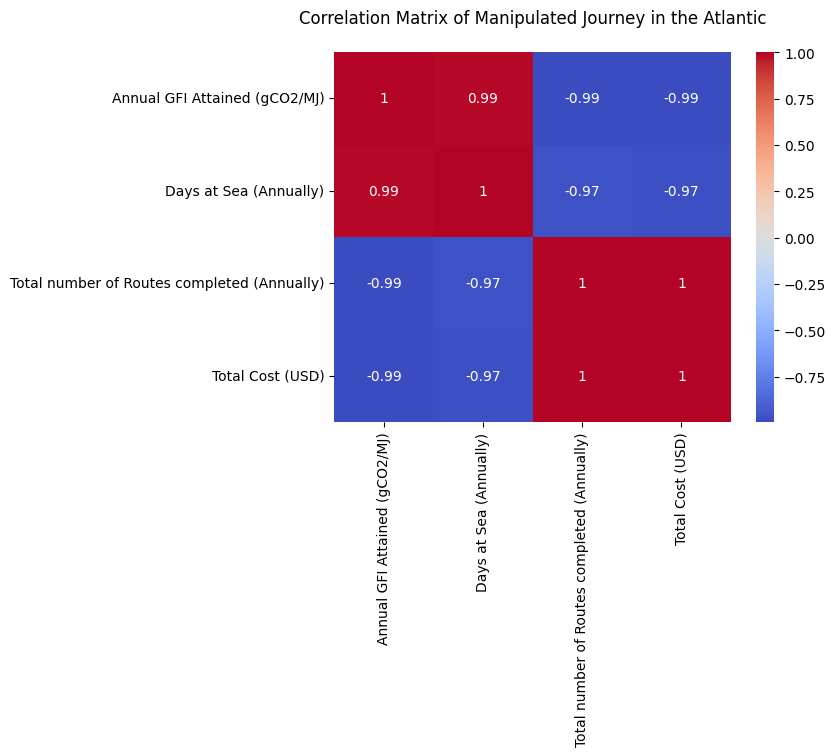

In [ ]:
correlation_matrix_atl_man = corr_atl_man[['Annual GFI Attained (gCO2/MJ)','Days at Sea (Annually)',
                                           'Total number of Routes completed (Annually)','Total Cost (USD)']].corr()

sns.heatmap(correlation_matrix_atl_man, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Manipulated Journey in the Atlantic\n")
plt.show()

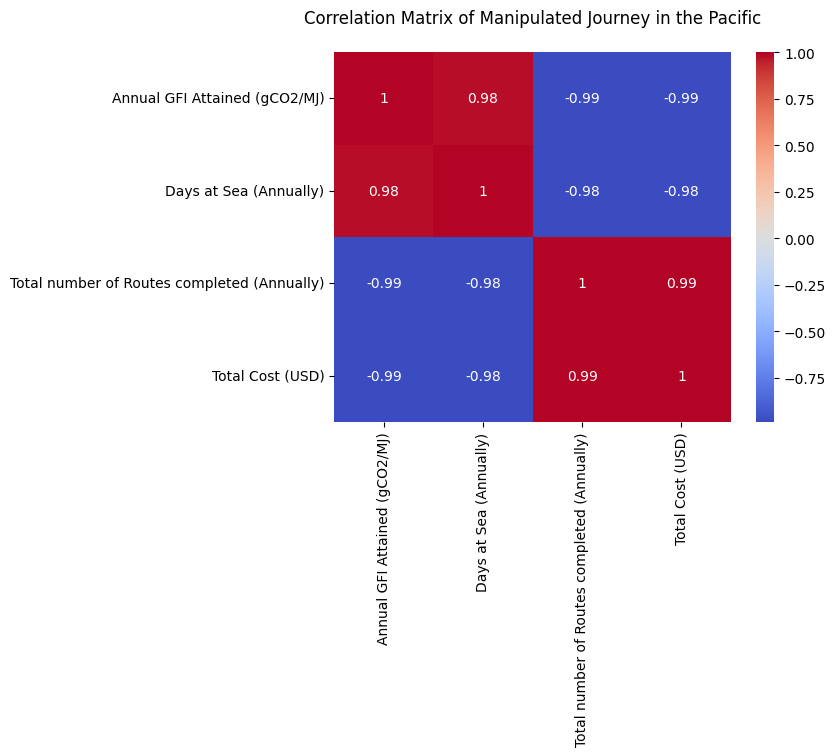

In [ ]:
correlation_matrix_pac_man = corr_pac_man[['Annual GFI Attained (gCO2/MJ)','Days at Sea (Annually)',
                                           'Total number of Routes completed (Annually)','Total Cost (USD)']].corr()

sns.heatmap(correlation_matrix_pac_man, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Manipulated Journey in the Pacific\n")
plt.show()

In [ ]:
v_max = container_performance['Speed_Over_Ground_knots'].max()
c_o = container_performance['Operational_Cost_USD'].mean() * 0.7
α = 3
F_MGO = ship_fuel_consumption_reporting.loc[1,'MGO_Consumption_per_Ship(liter/hour)']
F_VLSFO = ship_fuel_consumption_reporting.loc[1,'LFO_Consumption_per_Ship(liter/hour)']

operating_cost_ship = container_performance['Operational_Cost_USD'].mean() * 0.7

n = 0
total_journey_time = 0
journey_count = 0
time = total_journey_time
turn_around_time_hours = 0
down_time = 0
total_fuel_cons_ECA = 0
total_fuel_cons_Non_ECA = 0
total_energy = 0
op_cost = 0
cost_MGO = 0
cost_VLSFO = 0
op_cost = 0
journey_total = 0

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time <= 31:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"{journey_count} journeys in January")
print(f'\nThe speed in January inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in January outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in January is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in January is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 31 and time <= 59:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in February")
print(f'\nThe speed in February inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in February outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in February is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in February is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 59 and time <= 90:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in March")
print(f'\nThe speed in March inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in March outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in March is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in March is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 90 and time <= 120:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in April")
print(f'\nThe speed in April inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in April outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in April is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in April is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 120 and time <= 151:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in May")
print(f'\nThe speed in May inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in May outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in May is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in May is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 151 and time <= 181:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in June")
print(f'\nThe speed in June inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in June outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in June is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in June is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 181 and time <= 212:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in July")
print(f'\nThe speed in July inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in July outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in July is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in July is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 212 and time <= 243:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in August")
print(f'\nThe speed in August inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in August outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in August is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in August is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 243 and time <= 273:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in September")
print(f'\nThe speed in September inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in September outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in September is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in September is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 273 and time <= 304:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in October")
print(f'\nThe speed in October inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in October outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in October is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in October is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 304 and time <= 334:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in November")
print(f'\nThe speed in November inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in November outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in November is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in November is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count
turn_around_time_hours = 0
journey_count = 0
n+=1

for i in range(365):
  P_MGO = fuels.loc[n,'Marine Gas Oil']
  P_VLSFO = fuels.loc[n,'Very Low Sulfur Oil']

  if time > 334 and time <= 365:
    V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)
    V_0_ne = v_max * ((c_o * d_ne)/((α-1) * P_VLSFO * F_VLSFO))**(1/α)

    #prevention of stalling ship
    if V_0_e < container_performance['Speed_Over_Ground_knots'].min():
      V_0_e = container_performance['Speed_Over_Ground_knots'].min()
    else:
      V_0_e = v_max * ((c_o * d_e)/((α-1) * P_MGO * F_MGO))**(1/α)

    eca_journey_time = ((evas_1 / V_0_e) + (evas_2 / V_0_e))
    non_eca_journey_time = (non_eca_dist / V_0_ne)
    total_journey_time = ((evas_1 / V_0_e) + (non_eca_dist / V_0_ne) + (evas_2 / V_0_e)) / 24

    fuel_cons_ECA = eca_journey_time * F_MGO
    fuel_cons_Non_ECA = non_eca_journey_time * F_VLSFO
    total_fuel_cons_ECA += fuel_cons_ECA
    total_fuel_cons_Non_ECA += fuel_cons_Non_ECA

    journey_count += 1
    turn_around_time_hours += (ship_performance['Turnaround_Time_hours'].mean())
    time += total_journey_time
    time += ((ship_performance['Turnaround_Time_hours'].mean())/24)

    total_energy += container_performance['Power_Consumption_to_Time(MJ)'].mean()

    op_cost += operating_cost_ship
    cost_MGO += (fuel_cons_ECA / 2831.6846592) * P_MGO
    cost_VLSFO += (fuel_cons_Non_ECA / 2831.684659) * P_VLSFO

print(f"\n{journey_count} journeys in December")
print(f'\nThe speed in December inside an ECA is {V_0_e:.2f} knots')
print(f'The speed in December outside an ECA is {V_0_ne:.2f} knots')
print(f'The price of MGO in December is ${P_MGO:.2f}/mt')
print(f'The price of VLSFO in December is ${P_VLSFO:.2f}/mt')
print(f'turnaround time in hours is: {turn_around_time_hours:.3f}')

down_time += turn_around_time_hours
journey_total += journey_count

energy_mgo = total_energy
energy_vlsfo = total_energy

total_fuel_cons_ECA = total_fuel_cons_ECA * 1000 #Liters to grams
total_fuel_cons_Non_ECA = total_fuel_cons_Non_ECA * 1000 #Liters to grams

CO2_emissions_MGO_fuel_per_year = total_fuel_cons_ECA * 3.782
CO2_emissions_VLSFO_fuel_per_year = total_fuel_cons_Non_ECA * 3.734

GFI_MGO = CO2_emissions_MGO_fuel_per_year / energy_mgo
GFI_VLSFO = CO2_emissions_VLSFO_fuel_per_year / energy_vlsfo

GFI_2028_BT = (1-(4/100)) * 93.3
GFI_2028_DCT = (1-(17/100)) * 93.3
GFI_attained = (((GFI_MGO)*energy_mgo) + ((GFI_VLSFO)*energy_vlsfo)) / total_energy

Tier_1_deficit = (np.abs(((GFI_2028_DCT - GFI_2028_BT) * total_energy) / 1000000)) * 100
Tier_2_deficit = (np.abs(((GFI_2028_BT - GFI_attained) * total_energy)) / 1000000) * 380

print(f'\nTotal energy in reporting period is: {total_energy:.2f} MJ')
print()
print(f'GFI Base target for 2028 Annual GFI: {GFI_2028_BT:.2f} gCO2/MJ')
print(f'GFI attained on an annual basis: {GFI_attained:.2f} gCO2/MJ')
print()
print(f'Total number of Journeys: {journey_total}')
print()
print(f'{total_fuel_cons_ECA:.2f}g of MGO fuel')
print(f'{total_fuel_cons_Non_ECA:.2f}g of VLSFO fuel')
print(f'${Tier_1_deficit:.2f} IMO net zero remedial units owed per ship per year via Tier 1 deficit')
print(f'${Tier_2_deficit:.2f} IMO net zero remedial units owed per ship per year via Tier 2 deficit')
print(f'Total cost on an annual basis per ship is ${Tier_1_deficit+Tier_2_deficit+op_cost+cost_MGO+cost_VLSFO:.2f} on the route between {port} and {port_2}')
print(f'Total days at sea on an annual basis: {((time * 24) - down_time) / 24:.2f}')

4 journeys in January

The speed in January inside an ECA is 11.76 knots
The speed in January outside an ECA is 20.02 knots
The price of MGO in January is $854.02/mt
The price of VLSFO in January is $636.61/mt
turnaround time in hours is: 166.990

3 journeys in February

The speed in February inside an ECA is 11.63 knots
The speed in February outside an ECA is 19.80 knots
The price of MGO in February is $883.17/mt
The price of VLSFO in February is $658.21/mt
turnaround time in hours is: 125.243

3 journeys in March

The speed in March inside an ECA is 11.63 knots
The speed in March outside an ECA is 19.74 knots
The price of MGO in March is $882.86/mt
The price of VLSFO in March is $664.67/mt
turnaround time in hours is: 125.243

3 journeys in April

The speed in April inside an ECA is 11.64 knots
The speed in April outside an ECA is 19.70 knots
The price of MGO in April is $879.80/mt
The price of VLSFO in April is $668.75/mt
turnaround time in hours is: 125.243

3 journeys in May

The 

In [ ]:
Data = {
    'Route': [f'{port} to {port_2} (Controlled Journey)'],
    'Total number of Routes completed (Annually)': [journey_total],
    'Days at Sea (Annually)': ["{:.2f}".format(((time * 24) - down_time) / 24)],
    'Annual MGO CO2 emissions (tonnes)': ["{:.2f}".format(CO2_emissions_MGO_fuel_per_year/1000000)],
    'Annual VLSFO CO2 emissions (tonnes)': ["{:.2f}".format(CO2_emissions_VLSFO_fuel_per_year/1000000)],
    'Annual Total Energy (MJ)': ["{:.2f}".format(total_energy)],
    'Annual GFI Attained (gCO2/MJ)': ["{:.2f}".format(GFI_attained)],
    'Remedial Units - Tier 1 (USD)': ["{:.2f}".format(Tier_1_deficit)],
    'Remedial Units - Tier 2 (USD)': ["{:.2f}".format(Tier_2_deficit)],
    'Annual Operating Cost (USD)': ["{:.2f}".format(op_cost)],
    'Annual Cost MGO (USD)': ["{:.2f}".format(cost_MGO)],
    'Annual Cost VLSFO (USD)': ["{:.2f}".format(cost_VLSFO)],
    'Total Cost (USD)': ["{:.2f}".format(Tier_1_deficit+Tier_2_deficit+op_cost+cost_MGO+cost_VLSFO)],
}

dataframe = pd.DataFrame(Data)

dataframe.head()

,Route,Total number of Routes completed (Annually),Days at Sea (Annually),Annual MGO CO2 emissions (tonnes),Annual VLSFO CO2 emissions (tonnes),Annual Total Energy (MJ),Annual GFI Attained (gCO2/MJ),Remedial Units - Tier 1 (USD),Remedial Units - Tier 2 (USD),Annual Operating Cost (USD),Annual Cost MGO (USD),Annual Cost VLSFO (USD),Total Cost (USD)
0,Seattle to Honolulu (Controlled Journey),39,302.28,1583.06,4375.11,15439266.46,385.91,18726.29,1738614.99,7328241.96,120190.91,258837.51,9464611.66


In [ ]:
corr_data_pac_cont = {
    'Route': ["Seattle to Honolulu (Controlled Journey)","Seattle to Hilo (Controlled Journey)","Seattle to Kahului (Controlled Journey)",
              "Los Angeles to Honolulu (Controlled Journey)","Los Angeles to Hilo (Controlled Journey)","Los Angeles to Kahului (Controlled Journey)",
              "Oakland to Honolulu (Controlled Journey)","Oakland to Hilo (Controlled Journey)","Oakland to Kahului (Controlled Journey)"],
    'Total number of Routes completed (Annually)': [39,50,50,42,51,50,44,56,55],
    'Days at Sea (Annually)': [302.28,285.32,283.43,296.90,281.64,283.02,294.35,271.25,271.29],
    'Annual MGO CO2 emissions (tonnes)': [1583.06,2046.57,2056.19,847.65,1062.04,1044.29,1442.06,1886.72,1855.32],
    'Annual VLSFO CO2 emissions (tonnes)': [4375.11,3646.80,3602.41,4915.38,4437.20,4479.12,4347.21,3518.56,3546.67],
    'Annual Total Energy (MJ)': [15439266.46,19793931.36,19793931.36,16626902.34,20189809.99,19793931.36,17418659.60,22169203.12,21773324.49],
    'Annual GFI Attained (gCO2/MJ)': [385.91,287.63,285.88,346.61,272.38,279.05,332.36,243.82,248.10],
    'Remedial Units - Tier 1 (USD)': [18726.29,24008.06,24008.06,20166.77,24488.22,24008.06,21127.09,26889.03,26408.87],
    'Remedial Units - Tier 2 (USD)': [1738614.99,1489778.02,1476563.56,1624040.12,1402534.48,1425192.05,1607063.16,1299459.65,1311681.38],
    'Annual Operating Cost (USD)': [7328241.96,9395182.00,9395182.00,7891952.88,9583085.64,9395182.00,8267760.16,10522603.84,10334700.20],
    'Annual Cost MGO (USD)': [120190.91,155052.78,155781.10,64275.07,80536.06,79248.42,109364.84,142899.81,140810.04],
    'Annual Cost VLSFO (USD)': [258837.51,215477.78,212855.03,290629.63,262310.98,265012.32,257072.24,208018.26,209921.40],
    'Total Cost (USD)': [9464611.66,11279498.64,11264389.74,9891064.48,11352955.37,11188642.86,10262387.49,12199870.59,12023521.89],
}

corr_pac_cont = pd.DataFrame(corr_data_pac_cont)

In [ ]:
corr_data_atl_cont = {
    'Route': ["New York and New Jersey to San Juan (Controlled Journey)","Virginia to San Juan (Controlled Journey)",
              "Charleston to San Juan (Controlled Journey)","Savannah to San Juan (Controlled Journey)"],
    'Total number of Routes completed (Annually)': [72,74,82,81],
    'Days at Sea (Annually)': [241.49,240.12,225.86,227.96],
    'Annual MGO CO2 emissions (tonnes)': [1465.89,1543.66,1633.41,1603.48],
    'Annual VLSFO CO2 emissions (tonnes)': [3319.42,3225.33,2875.14,2941.47],
    'Annual Total Energy (MJ)': [28503261.16,29295018.41,32462047.43,32066168.80],
    'Annual GFI Attained (gCO2/MJ)': [167.89,162.79,138.89,141.74],
    'Remedial Units - Tier 1 (USD)': [34571.61,35531.93,39373.22,38893.06],
    'Remedial Units - Tier 2 (USD)': [848284.86,815134.10,608375.02,635680.92],
    'Annual Operating Cost (USD)': [13529062.08,13904869.36,15408098.48,15220194.84],
    'Annual Cost MGO (USD)': [111221.26,117046.77,123870.12,121710.81],
    'Annual Cost VLSFO (USD)': [196422.52,190692.67,170106.89,174082.18],
    'Total Cost (USD)': [14719562.32,15063274.84,16349823.73,16190561.80],
}

corr_atl_cont = pd.DataFrame(corr_data_atl_cont)

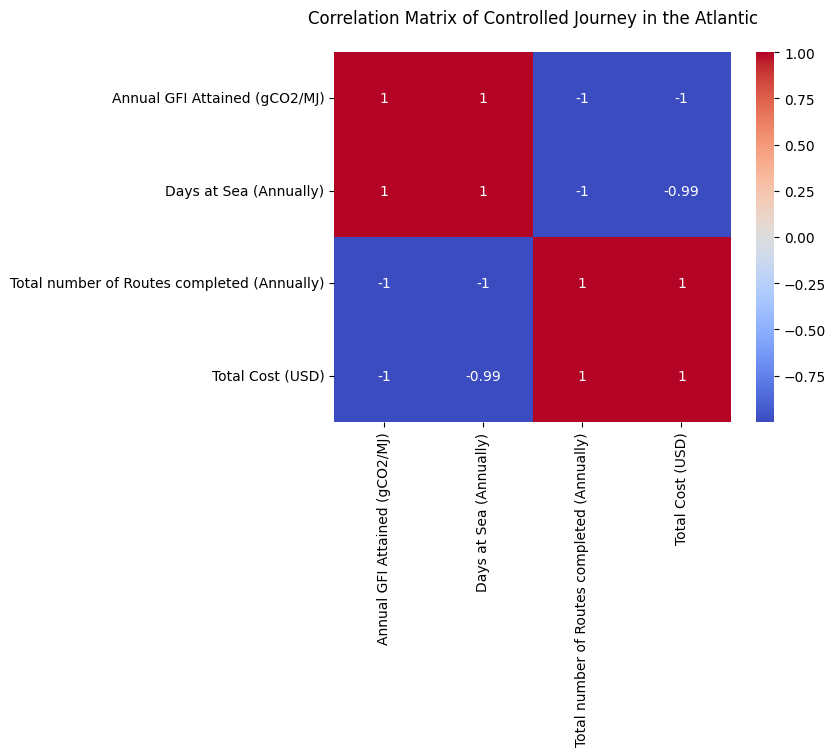

In [ ]:
correlation_matrix_con_atl = corr_atl_cont[['Annual GFI Attained (gCO2/MJ)','Days at Sea (Annually)',
                                            'Total number of Routes completed (Annually)','Total Cost (USD)']].corr()

sns.heatmap(correlation_matrix_con_atl, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Controlled Journey in the Atlantic\n")
plt.show()

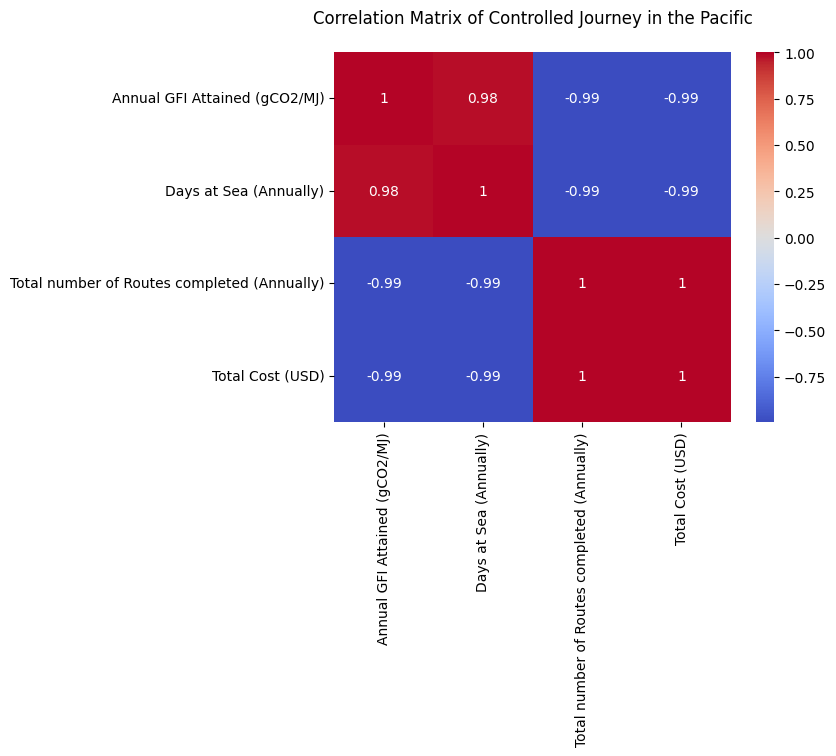

In [ ]:
correlation_matrix_con_pac = corr_pac_cont[['Annual GFI Attained (gCO2/MJ)','Days at Sea (Annually)',
                                            'Total number of Routes completed (Annually)','Total Cost (USD)']].corr()

sns.heatmap(correlation_matrix_con_pac, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Controlled Journey in the Pacific\n")
plt.show()

In [ ]:
total_cost_man_pac = corr_data_pac_man['Total Cost (USD)']
total_cost_con_pac = corr_data_pac_cont['Total Cost (USD)']

t_stat, p_val = ttest_ind(total_cost_man_pac, total_cost_con_pac)

Explanation = "Reject null: cost differs between manipulated journey and controlled journey in the pacific." if p_val < 0.05 else "Fail to reject null: no significant cost difference."
print("\n--- Hypothesis Test Results (Pacific) ---")
print(f"\nTwo-sample t-test: t = {t_stat:.3f}, α = {1-p_val:.4f}, p = {p_val:.4f} → {Explanation}")


--- Hypothesis Test Results (Pacific) ---

Two-sample t-test: t = 0.002, α = 0.0017, p = 0.9983 → Fail to reject null: no significant cost difference.


In [ ]:
total_cost_man_atl = corr_data_atl_man['Total Cost (USD)']
total_cost_con_atl = corr_data_atl_cont['Total Cost (USD)']

t_stat, p_val = ttest_ind(total_cost_man_atl, total_cost_con_atl)

Explanation = "Reject null: cost differs between manipulated journey and controlled journey in the Atlantic." if p_val < 0.05 else "Fail to reject null: no significant cost difference."
print("\n--- Hypothesis Test Results (Atlantic) ---")
print(f"\nTwo-sample t-test: t = {t_stat:.3f}, α = {1-p_val:.4f}, p = {p_val:.4f} → {Explanation}")


--- Hypothesis Test Results (Atlantic) ---

Two-sample t-test: t = -0.065, α = 0.0500, p = 0.9500 → Fail to reject null: no significant cost difference.
